# ESA GeoFM Challenge — Dual-Branch Fusion (AlphaEarth + TerraMind S2)

**Branches:**
- **AlphaEarth** (64ch, 256×256) — native resolution, sharp spatial detail → builds/water IoU
- **TerraMind S2** (768ch, 16×16) → upsample to 256×256 → height context, veg height

**Output:** 4-band prediction — build%, veg%, water%, nDSM height (metres)

**Scoring weights:** mIoU_build×0.25 + mIoU_trees×0.15 + mIoU_water×0.15 + RMSE_H_build×0.25 + RMSE_H_veg×0.20


## 0 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=False)


Mounted at /content/drive


## 1 — Imports & config

In [ ]:
import re, random, warnings, shutil, zipfile
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio
warnings.filterwarnings('ignore', category=rasterio.errors.NotGeoreferencedWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
DRIVE_ROOT  = Path('/content/drive/MyDrive/ESA_Challenge')
AE_TRAIN    = DRIVE_ROOT / 'train' / 'alphaearth_emb'
TM_TRAIN    = DRIVE_ROOT / 'train' / 'terramind_s2_emb'
LABEL_DIR   = DRIVE_ROOT / 'train' / 'labels'
AE_TEST     = DRIVE_ROOT / 'test'  / 'alphaearth_emb'
TM_TEST     = DRIVE_ROOT / 'test'  / 'terramind_test_s2_emb'
NORM_STATS  = DRIVE_ROOT / 'norm_stats.npy'
CKPT_PATH   = DRIVE_ROOT / 'best_model_dual.pth'

# ── Hyperparams ───────────────────────────────────────────────────────────────
BATCH_SIZE = 8      # reduced from 16 — two branches use more VRAM
EPOCHS     = 40
LR         = 3e-4
VAL_FRAC   = 0.15
SEED       = 42
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print('Device:', DEVICE)
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Keep-alive: prevents Colab disconnecting when tab is idle ─────────────────
from IPython.display import display, Javascript
display(Javascript("""
setInterval(() => {
  document.querySelectorAll('colab-toolbar-button#connect').forEach(b => b.click());
}, 60000);
console.log('Keep-alive active');
"""))


Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


<IPython.core.display.Javascript object>

## 2 — Copy train data to local SSD

In [ ]:
from google.colab import drive as _drive

LOCAL_AE  = Path('/content/train_ae')
LOCAL_TM  = Path('/content/train_tm')
LOCAL_LBL = Path('/content/train_labels')
for p in [LOCAL_AE, LOCAL_TM, LOCAL_LBL]:
    p.mkdir(exist_ok=True)

def safe_copy(src: Path, dst: Path):
    try:
        shutil.copy2(src, dst)
    except OSError:
        _drive.mount('/content/drive', force_remount=True)
        shutil.copy2(src, dst)

for src_dir, dst_dir, label in [
    (AE_TRAIN,  LOCAL_AE,  'AlphaEarth'),
    (TM_TRAIN,  LOCAL_TM,  'TerraMind S2'),
    (LABEL_DIR, LOCAL_LBL, 'Labels'),
]:
    files = sorted(src_dir.glob('*.tif'))
    print(f'Copying {len(files)} {label} files → SSD…')
    for p in files:
        dst = dst_dir / p.name
        if not dst.exists():
            safe_copy(p, dst)

print(f'Done. AE={len(list(LOCAL_AE.glob("*.tif")))}  '
      f'TM={len(list(LOCAL_TM.glob("*.tif")))}  '
      f'Labels={len(list(LOCAL_LBL.glob("*.tif")))}')


Copying 2024 AlphaEarth files → SSD…
Mounted at /content/drive
Copying 2024 TerraMind S2 files → SSD…
Copying 2024 Labels files → SSD…
Done. AE=2024  TM=2024  Labels=2024


## 2b — Pre-normalize AlphaEarth → float16 .npy (run once, ~3 min)

In [ ]:
LOCAL_AE_NPY = Path('/content/train_ae_npy')
LOCAL_AE_NPY.mkdir(exist_ok=True)

stats_tmp = np.load(NORM_STATS, allow_pickle=True).item()
_ae_mean = stats_tmp['alphaearth_emb']['mean'].reshape(-1,1,1).astype(np.float32)
_ae_std  = stats_tmp['alphaearth_emb']['std'].reshape(-1,1,1).astype(np.float32)

tif_files   = sorted(LOCAL_AE.glob('*.tif'))
npy_missing = [f for f in tif_files
               if not (LOCAL_AE_NPY / (f.stem + '.npy')).exists()]
print(f'Pre-normalizing {len(npy_missing)} AlphaEarth files → float16 .npy…')

for p in npy_missing:
    with rasterio.open(p) as src:
        arr = src.read().astype(np.float32)
    if arr.shape[-1] != 256 or arr.shape[-2] != 256:
        t = torch.from_numpy(arr).unsqueeze(0)
        t = F.interpolate(t, size=(256,256), mode='bilinear', align_corners=False)
        arr = t.squeeze(0).numpy()
    arr = (arr - _ae_mean) / (_ae_std + 1e-6)
    arr = np.nan_to_num(arr, nan=0.0).astype(np.float16)
    np.save(LOCAL_AE_NPY / (p.stem + '.npy'), arr)

print(f'Done. {len(list(LOCAL_AE_NPY.glob("*.npy")))} .npy files ready.')


Pre-normalizing 2024 AlphaEarth files → float16 .npy…
Done. 2024 .npy files ready.


## 3 — Norm stats

In [ ]:
stats = np.load(NORM_STATS, allow_pickle=True).item()
assert 'alphaearth_emb'   in stats, 'Missing alphaearth_emb in norm_stats!'
assert 'terramind_s2_emb' in stats, 'Missing terramind_s2_emb in norm_stats!'

AE_MEAN = stats['alphaearth_emb']['mean'].reshape(-1,1,1).astype(np.float32)
AE_STD  = stats['alphaearth_emb']['std'].reshape(-1,1,1).astype(np.float32)
TM_MEAN = stats['terramind_s2_emb']['mean'].reshape(-1,1,1).astype(np.float32)
TM_STD  = stats['terramind_s2_emb']['std'].reshape(-1,1,1).astype(np.float32)
print(f'AE  norm: {AE_MEAN.shape[0]}ch  TM norm: {TM_MEAN.shape[0]}ch')


AE  norm: 64ch  TM norm: 768ch


## 4 — Dataset

In [ ]:
def patch_id(stem: str):
    m = re.search(r'_(\d{4})_', stem)
    return m.group(1) if m else None

def load_tif(path: Path, target_hw=None) -> np.ndarray:
    with rasterio.open(path) as src:
        arr = src.read().astype(np.float32)
    if target_hw and (arr.shape[-1] != target_hw or arr.shape[-2] != target_hw):
        t = torch.from_numpy(arr).unsqueeze(0)
        t = F.interpolate(t, size=(target_hw, target_hw),
                          mode='bilinear', align_corners=False)
        arr = t.squeeze(0).numpy()
    return arr


class DualBranchDataset(Dataset):
    """
    Returns:
        ae   : (64,  256, 256) float32 — AlphaEarth, pre-normalized
        tm   : (768,  16,  16) float32 — TerraMind S2, normalized on-the-fly
        seg  : (3,   256, 256) float32 — build/veg/water [0,1]
        height: (1,  256, 256) float32 — log1p(metres)
    """
    def __init__(self, ae_files, tm_files, lbl_files, augment=False):
        self.ae_files  = ae_files
        self.tm_files  = tm_files
        self.lbl_files = lbl_files
        self.augment   = augment

    def __len__(self):
        return len(self.ae_files)

    def __getitem__(self, idx):
        try:
            ae  = np.load(self.ae_files[idx]).astype(np.float32)   # pre-normed
            tm  = load_tif(self.tm_files[idx])                      # (768,16,16)
            lbl = load_tif(self.lbl_files[idx], target_hw=256)      # (4,256,256)
        except Exception:
            ae  = np.zeros((64,  256, 256), dtype=np.float32)
            tm  = np.zeros((768,  16,  16), dtype=np.float32)
            lbl = np.zeros((4,   256, 256), dtype=np.float32)

        # Normalize TerraMind on-the-fly (16x16, fast)
        tm = (tm - TM_MEAN) / (TM_STD + 1e-6)
        tm = np.nan_to_num(tm, nan=0.0)

        seg    = lbl[:3].clip(0, 1)
        height = np.log1p(lbl[3:4].clip(0, None))

        ae     = torch.from_numpy(ae)
        tm     = torch.from_numpy(tm)
        seg    = torch.from_numpy(seg)
        height = torch.from_numpy(height)

        if self.augment:
            # Horizontal flip
            if random.random() > 0.5:
                ae = torch.flip(ae, [-1]); tm = torch.flip(tm, [-1])
                seg = torch.flip(seg, [-1]); height = torch.flip(height, [-1])
            # Vertical flip
            if random.random() > 0.5:
                ae = torch.flip(ae, [-2]); tm = torch.flip(tm, [-2])
                seg = torch.flip(seg, [-2]); height = torch.flip(height, [-2])
            # 90° rotations
            k = random.randint(0, 3)
            if k > 0:
                ae     = torch.rot90(ae,     k, dims=[-2,-1])
                tm     = torch.rot90(tm,     k, dims=[-2,-1])
                seg    = torch.rot90(seg,    k, dims=[-2,-1])
                height = torch.rot90(height, k, dims=[-2,-1])

        return ae, tm, seg, height


# ── Build matched file lists ──────────────────────────────────────────────────
ae_map  = {patch_id(p.stem): p for p in LOCAL_AE_NPY.glob('*.npy') if patch_id(p.stem)}
tm_map  = {patch_id(p.stem): p for p in LOCAL_TM.glob('*.tif')     if patch_id(p.stem)}
lbl_map = {patch_id(p.stem): p for p in LOCAL_LBL.glob('*.tif')    if patch_id(p.stem)}

common  = sorted(ae_map.keys() & tm_map.keys() & lbl_map.keys())
print(f'Matched patches (all 3 branches): {len(common)}')

random.shuffle(common)
n_val   = int(len(common) * VAL_FRAC)
val_ids = common[:n_val]
trn_ids = common[n_val:]

trn_ds = DualBranchDataset(
    [ae_map[i] for i in trn_ids], [tm_map[i] for i in trn_ids],
    [lbl_map[i] for i in trn_ids], augment=True)
val_ds = DualBranchDataset(
    [ae_map[i] for i in val_ids], [tm_map[i] for i in val_ids],
    [lbl_map[i] for i in val_ids], augment=False)

trn_loader = DataLoader(trn_ds, batch_size=BATCH_SIZE, shuffle=True,
                        num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=0, pin_memory=True)
print(f'Train: {len(trn_ds)}  Val: {len(val_ds)}')

# Smoke test
ae_s, tm_s, seg_s, ht_s = trn_ds[0]
print(f'AE: {ae_s.shape}  TM: {tm_s.shape}  seg: {seg_s.shape}  ht: {ht_s.shape}')


Matched patches (all 3 branches): 2024
Train: 1721  Val: 303
AE: torch.Size([64, 256, 256])  TM: torch.Size([768, 16, 16])  seg: torch.Size([3, 256, 256])  ht: torch.Size([1, 256, 256])


## 5 — Model: DualBranchFusion

In [ ]:
class ConvBnRelu(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


class DualBranchFusion(nn.Module):
    """
    Branch A — AlphaEarth : (B, 64,  256, 256) — native res, spatial detail
    Branch B — TerraMind  : (B, 768,  16,  16) → 1x1 conv reduce → upsample to 256

    Fusion: concat at 256×256 → shared decoder → seg + height heads
    """
    def __init__(self, ae_ch=64, tm_ch=768, fuse_ch=128):
        super().__init__()

        # Branch A: refine AlphaEarth spatial features
        self.ae_encoder = nn.Sequential(
            ConvBnRelu(ae_ch, 128),
            ConvBnRelu(128,    64),
        )  # → (B, 64, 256, 256)

        # Branch B: compress TerraMind 768→64, then upsample
        self.tm_encoder = nn.Sequential(
            nn.Conv2d(tm_ch, 256, 1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256,    64, 1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
        )  # → (B, 64, 16, 16) then upsample → (B, 64, 256, 256)

        # Shared decoder after concat (64 + 64 = 128 channels)
        self.decoder = nn.Sequential(
            ConvBnRelu(128, 128),
            ConvBnRelu(128,  64),
            ConvBnRelu(64,   64),
        )

        self.seg_head    = nn.Conv2d(64, 3, 1)   # raw logits
        self.height_head = nn.Conv2d(64, 1, 1)

    def forward(self, ae, tm):
        # Branch A
        a = self.ae_encoder(ae)                                    # (B, 64, 256, 256)

        # Branch B
        b = self.tm_encoder(tm)                                    # (B, 64,  16,  16)
        b = F.interpolate(b, size=(256, 256),
                          mode='bilinear', align_corners=False)    # (B, 64, 256, 256)

        # Fuse + decode
        x   = torch.cat([a, b], dim=1)                            # (B, 128, 256, 256)
        x   = self.decoder(x)                                      # (B,  64, 256, 256)

        seg    = self.seg_head(x)                                  # logits — sigmoid at loss
        height = F.softplus(self.height_head(x))                  # >= 0, log1p space
        return seg, height


model    = DualBranchFusion().to(DEVICE)
model    = torch.compile(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Parameters: {n_params:,}')

# Smoke test
with torch.no_grad():
    _ae = torch.randn(2, 64,  256, 256).to(DEVICE)
    _tm = torch.randn(2, 768,  16,  16).to(DEVICE)
    _s, _h = model(_ae, _tm)
print(f'Output — seg:{_s.shape}  height:{_h.shape}')
if DEVICE.type == 'cuda':
    print(f'VRAM used: {torch.cuda.memory_allocated()/1e9:.2f} GB')


Parameters: 620,292


W0603 07:26:51.452000 2663 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode


Output — seg:torch.Size([2, 3, 256, 256])  height:torch.Size([2, 1, 256, 256])
VRAM used: 0.04 GB


## 6 — Loss & metrics

In [ ]:
def seg_loss(logits, target):
    w   = torch.tensor([5.0, 1.0, 1.0], device=logits.device).view(1, 3, 1, 1)
    bce = F.binary_cross_entropy_with_logits(logits, target, reduction='none')
    return (bce * w).mean()

def dice_loss_buildings(logits, target, eps=1e-6):
    p     = torch.sigmoid(logits[:, 0])
    t     = target[:, 0]
    inter = (p * t).sum()
    return 1 - (2 * inter + eps) / (p.sum() + t.sum() + eps)

def height_loss(pred, target):
    w = 1.0 + (target > 0).float() * 2.0
    return (w * F.huber_loss(pred, target, delta=1.0, reduction='none')).mean()

def total_loss(logits, height, seg_t, height_t, lam=1.5):
    return (seg_loss(logits, seg_t)
            + 2.0 * dice_loss_buildings(logits, seg_t)
            + lam  * height_loss(height, height_t))

@torch.no_grad()
def compute_miou(logits, target, thresh=0.5):
    p     = (torch.sigmoid(logits) > thresh).float()
    t     = (target > thresh).float()
    inter = (p * t).sum(dim=(0, 2, 3))
    union = (p + t - p * t).sum(dim=(0, 2, 3))
    iou   = inter / (union + 1e-6)
    return iou.mean().item(), iou[0].item(), iou[1].item(), iou[2].item()

@torch.no_grad()
def compute_rmse(pred, target):
    p = torch.expm1(pred).clamp(0)
    t = torch.expm1(target).clamp(0)
    return torch.sqrt(F.mse_loss(p, t)).item()

print('Loss & metrics defined.')

Loss & metrics defined.


## 7 — Training loop

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=EPOCHS, eta_min=LR/20)
scaler    = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
history       = []

for epoch in range(1, EPOCHS + 1):
    # ── Train ─────────────────────────────────────────────────────────────────
    model.train()
    trn_loss = 0.0
    for ae, tm, seg_t, h_t in trn_loader:
        ae, tm    = ae.to(DEVICE), tm.to(DEVICE)
        seg_t, h_t = seg_t.to(DEVICE), h_t.to(DEVICE)

        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            seg_p, h_p = model(ae, tm)
            loss = total_loss(seg_p, h_p, seg_t, h_t)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        trn_loss += loss.item()
    trn_loss /= len(trn_loader)

    # ── Val ───────────────────────────────────────────────────────────────────
    model.eval()
    val_loss = 0.0
    all_seg_p, all_seg_t, all_h_p, all_h_t = [], [], [], []
    with torch.no_grad():
        for ae, tm, seg_t, h_t in val_loader:
            ae, tm    = ae.to(DEVICE), tm.to(DEVICE)
            seg_t, h_t = seg_t.to(DEVICE), h_t.to(DEVICE)
            with torch.amp.autocast('cuda'):
                seg_p, h_p = model(ae, tm)
                val_loss  += total_loss(seg_p, h_p, seg_t, h_t).item()
            all_seg_p.append(seg_p.float().cpu())
            all_seg_t.append(seg_t.float().cpu())
            all_h_p.append(h_p.float().cpu())
            all_h_t.append(h_t.float().cpu())
    val_loss /= len(val_loader)

    miou, iou_b, iou_v, iou_w = compute_miou(
        torch.cat(all_seg_p), torch.cat(all_seg_t))
    rmse_h = compute_rmse(torch.cat(all_h_p), torch.cat(all_h_t))
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        ckpt = {'epoch': epoch, 'model': model.state_dict(),
                'val_loss': best_val_loss}
        torch.save(ckpt, CKPT_PATH)
        tag = ' ✓'
    else:
        tag = ''

    history.append(dict(epoch=epoch, trn=trn_loss, val=val_loss,
                        miou=miou, iou_b=iou_b, iou_v=iou_v,
                        iou_w=iou_w, rmse_h=rmse_h))

    if epoch % 5 == 0 or epoch == 1:
        print(f'Ep {epoch:03d} | trn={trn_loss:.4f} val={val_loss:.4f} | '
              f'mIoU={miou:.3f} (b={iou_b:.3f} v={iou_v:.3f} w={iou_w:.3f}) '
              f'RMSE_H={rmse_h:.2f}m{tag}')

print(f'\nBest val_loss={best_val_loss:.4f} → {CKPT_PATH}')


Ep 001 | trn=3.3447 val=2.6889 | mIoU=0.305 (b=0.155 v=0.761 w=0.000) RMSE_H=3.00m ✓
Ep 005 | trn=1.8869 val=1.8366 | mIoU=0.516 (b=0.254 v=0.818 w=0.477) RMSE_H=2.93m ✓
Ep 010 | trn=1.7570 val=1.7560 | mIoU=0.559 (b=0.265 v=0.826 w=0.584) RMSE_H=2.78m ✓
Ep 015 | trn=1.7147 val=1.7315 | mIoU=0.569 (b=0.269 v=0.826 w=0.614) RMSE_H=2.59m ✓
Ep 020 | trn=1.6732 val=1.7279 | mIoU=0.571 (b=0.271 v=0.824 w=0.619) RMSE_H=2.63m
Ep 025 | trn=1.6396 val=1.7283 | mIoU=0.575 (b=0.269 v=0.830 w=0.626) RMSE_H=2.63m
Ep 030 | trn=1.6292 val=1.7228 | mIoU=0.574 (b=0.266 v=0.826 w=0.629) RMSE_H=2.68m
Ep 035 | trn=1.6120 val=1.7132 | mIoU=0.574 (b=0.269 v=0.825 w=0.629) RMSE_H=2.58m ✓
Ep 040 | trn=1.6090 val=1.7185 | mIoU=0.575 (b=0.266 v=0.825 w=0.633) RMSE_H=2.55m

Best val_loss=1.7123 → /content/drive/MyDrive/ESA_Challenge/best_model_dual.pth


## 8 — Training curves

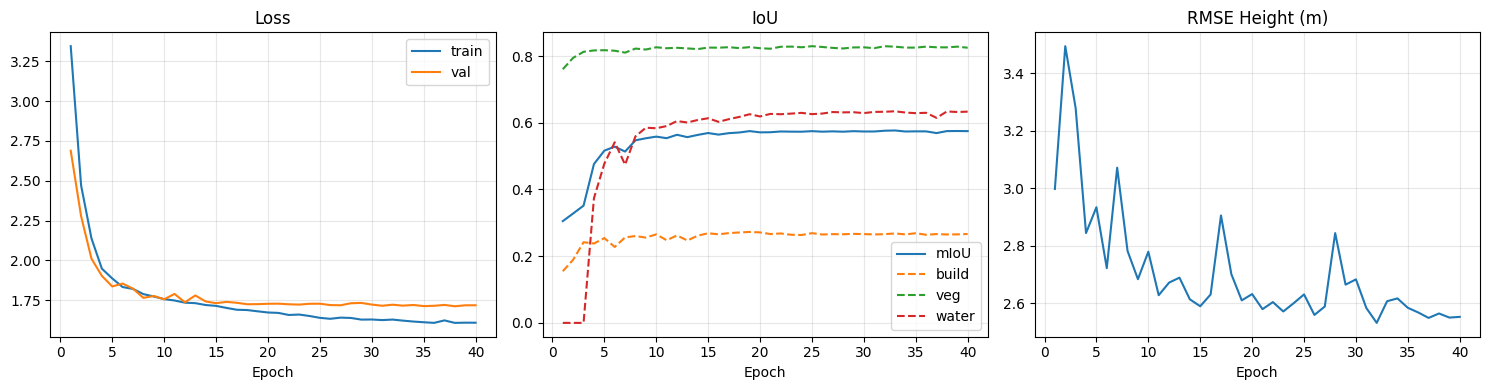

 epoch      trn      val     miou    iou_b    iou_v    iou_w   rmse_h
    36 1.608021 1.715201 0.574256 0.264293 0.828458 0.630015 2.567518
    37 1.623583 1.720773 0.569187 0.266302 0.826439 0.614820 2.548536
    38 1.607936 1.712275 0.575137 0.265100 0.826221 0.634091 2.564060
    39 1.609264 1.718245 0.575389 0.265416 0.828362 0.632390 2.549806
    40 1.609025 1.718479 0.575024 0.266487 0.825127 0.633459 2.552211


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df  = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df.epoch, df.trn, label='train')
axes[0].plot(df.epoch, df.val, label='val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(df.epoch, df.miou,  label='mIoU')
axes[1].plot(df.epoch, df.iou_b, label='build', linestyle='--')
axes[1].plot(df.epoch, df.iou_v, label='veg',   linestyle='--')
axes[1].plot(df.epoch, df.iou_w, label='water', linestyle='--')
axes[1].set_title('IoU'); axes[1].legend()

axes[2].plot(df.epoch, df.rmse_h)
axes[2].set_title('RMSE Height (m)')

for ax in axes: ax.set_xlabel('Epoch'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(df.tail(5).to_string(index=False))


## 9 — Copy test files to local SSD

In [ ]:
LOCAL_TEST_AE = Path('/content/test_ae')
LOCAL_TEST_TM = Path('/content/test_tm')
LOCAL_TEST_AE.mkdir(exist_ok=True)
LOCAL_TEST_TM.mkdir(exist_ok=True)

for src_dir, dst_dir, label in [
    (AE_TEST, LOCAL_TEST_AE, 'AE test'),
    (TM_TEST, LOCAL_TEST_TM, 'TM test'),
]:
    files = sorted(src_dir.glob('*.tif'))
    print(f'Copying {len(files)} {label} files…')
    for p in files:
        dst = dst_dir / p.name
        if not dst.exists():
            safe_copy(p, dst)

print(f'AE test: {len(list(LOCAL_TEST_AE.glob("*.tif")))}  '
      f'TM test: {len(list(LOCAL_TEST_TM.glob("*.tif")))}')


Copying 946 AE test files…
Mounted at /content/drive
Copying 946 TM test files…
AE test: 946  TM test: 946


## 10 — Inference & submission

In [ ]:
# Load best checkpoint
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
try:
    model.load_state_dict(ckpt['model'])
except RuntimeError:
    model._orig_mod.load_state_dict(ckpt['model'])
model.eval()
print(f'Loaded checkpoint epoch {ckpt["epoch"]}  val_loss={ckpt["val_loss"]:.4f}')

# Index test files by patch_id
ae_test_map = {patch_id(p.stem): p
               for p in LOCAL_TEST_AE.glob('*.tif') if patch_id(p.stem)}
tm_test_map = {patch_id(p.stem): p
               for p in LOCAL_TEST_TM.glob('*.tif') if patch_id(p.stem)}
test_ids    = sorted(ae_test_map.keys() & tm_test_map.keys())
print(f'Test patches (both branches): {len(test_ids)}')

SUB_PRED = Path('/content/predictions')
SUB_PRED.mkdir(exist_ok=True)

for pid in test_ids:
    ae_path = ae_test_map[pid]
    tm_path = tm_test_map[pid]

    # AlphaEarth: load tif, normalize
    ae = load_tif(ae_path, target_hw=256).astype(np.float32)
    ae = (ae - AE_MEAN) / (AE_STD + 1e-6)
    ae = np.nan_to_num(ae, nan=0.0)

    # TerraMind: load tif, normalize
    tm = load_tif(tm_path).astype(np.float32)
    tm = (tm - TM_MEAN) / (TM_STD + 1e-6)
    tm = np.nan_to_num(tm, nan=0.0)

    ae_t = torch.from_numpy(ae).unsqueeze(0).to(DEVICE)   # (1, 64, 256, 256)
    tm_t = torch.from_numpy(tm).unsqueeze(0).to(DEVICE)   # (1, 768, 16, 16)

    with torch.no_grad(), torch.amp.autocast('cuda'):
        seg_logits, h_p = model(ae_t, tm_t)

    seg_np = torch.sigmoid(seg_logits).squeeze(0).float().cpu().numpy()  # (3,256,256)
    h_np   = torch.expm1(h_p).clamp(0).squeeze(0).float().cpu().numpy() # metres
    pred   = np.concatenate([seg_np, h_np], axis=0).astype(np.float32)  # (4,256,256)

    # Naming: s2_3335_MM_2022_embeddings → 3335_MM_2022.npy
    stem  = tm_path.stem
    clean = re.sub(r'^s2_', '', stem)
    clean = re.sub(r'_embeddings$', '', clean)
    np.save(SUB_PRED / f'{clean}.npy', pred)

n_saved = len(list(SUB_PRED.glob('*.npy')))
print(f'Saved {n_saved} prediction files.')

SUB_ZIP = DRIVE_ROOT / 'submission_dual.zip'
with zipfile.ZipFile(SUB_ZIP, 'w', zipfile.ZIP_DEFLATED) as zf:
    for npy in sorted(SUB_PRED.glob('*.npy')):
        zf.write(npy, f'predictions/{npy.name}')
print(f'Zip saved: {SUB_ZIP}  ({SUB_ZIP.stat().st_size/1e6:.1f} MB)')


Loaded checkpoint epoch 38  val_loss=1.7123
Test patches (both branches): 946
Saved 946 prediction files.
Zip saved: /content/drive/MyDrive/ESA_Challenge/submission_dual.zip  (489.0 MB)


## 11 — Sanity check

In [ ]:
with zipfile.ZipFile(SUB_ZIP) as zf:
    names = zf.namelist()
    print(f'Files in zip: {len(names)}')
    arr = np.load(zf.open(names[0]))
    print(f'Shape : {arr.shape}')            # (4, 256, 256)
    print(f'Build : {arr[0].min():.3f} – {arr[0].max():.3f}')
    print(f'Veg   : {arr[1].min():.3f} – {arr[1].max():.3f}')
    print(f'Water : {arr[2].min():.3f} – {arr[2].max():.3f}')
    print(f'Height: {arr[3].min():.1f}m – {arr[3].max():.1f}m')


Files in zip: 946
Shape : (4, 256, 256)
Build : 0.000 – 0.998
Veg   : 0.000 – 1.000
Water : 0.000 – 0.151
Height: 0.0m – 19.9m
